In [1]:
# Authenticate with Google and connect to BigQuery

from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

client = bigquery.Client(project='deprivation-spending-analysis')
print("Connected to BigQuery successfully")

Connected to BigQuery successfully


In [2]:
# Load the mart table from BigQuery
# This is the core analytical table with 1,733 rows
# One row per local authority per financial year (2019-20 to 2024-25)
query = """
SELECT *
FROM `deprivation-spending-analysis.spending_analysis_marts.mart_deprivation_spending`
ORDER BY lad_code, financial_year_start
"""

df = client.query(query).to_dataframe()

print(f"Rows loaded: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFinancial years: {sorted(df['financial_year_start'].unique())}")
print(f"Authorities per year:")
print(df.groupby('financial_year_start')['lad_code'].count())
print(f"\nRegions: {sorted(df['region_name'].unique())}")
print(f"\nAuthority classes: {sorted(df['la_class'].unique())}")

Rows loaded: 1733
Columns: ['year_ending', 'financial_year_start', 'lad_code', 'la_name', 'la_class', 'la_subclass', 'imd_score', 'imd_rank', 'imd_proportion_deprived_10pct', 'net_current_expenditure', 'total_service_expenditure', 'adult_social_care_expenditure', 'childrens_social_care_expenditure', 'population', 'net_current_expenditure_per_capita', 'total_service_expenditure_per_capita', 'adult_social_care_per_capita', 'childrens_social_care_per_capita', 'is_covid_year', 'region_name']

Financial years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Authorities per year:
financial_year_start
2019    289
2020    290
2021    292
2022    292
2023    283
2024    287
Name: lad_code, dtype: int64

Regions: ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands', 'Yorkshire and The Humber']

Authority classes: ['London', 'Met District', 'Shire District', 'Unitary Authority']


In [3]:
# Descriptive statistics for the key variables
# This gives us a first look at the data before running any models
# Important for spotting outliers or unexpected values

print("=== KEY VARIABLE SUMMARY ===\n")

key_vars = [
    'imd_score',
    'net_current_expenditure_per_capita',
    'total_service_expenditure_per_capita',
    'adult_social_care_per_capita',
    'childrens_social_care_per_capita',
    'population'
]

print(df[key_vars].describe().round(2))

print("\n=== SPENDING BY REGION (average net current expenditure per capita) ===\n")
print(df.groupby('region_name')['net_current_expenditure_per_capita'].mean().round(2).sort_values(ascending=False))

print("\n=== SPENDING BY AUTHORITY CLASS ===\n")
print(df.groupby('la_class')['net_current_expenditure_per_capita'].mean().round(2).sort_values(ascending=False))

print("\n=== DEPRIVATION BY REGION (average IMD score) ===\n")
print(df.groupby('region_name')['imd_score'].mean().round(2).sort_values(ascending=False))

=== KEY VARIABLE SUMMARY ===

       imd_score  net_current_expenditure_per_capita  \
count    1733.00                             1733.00   
mean       20.11                             1149.94   
std         7.96                             1684.89   
min         5.91                              -80.14   
25%        13.75                              319.25   
50%        19.02                              415.26   
75%        25.61                             1852.54   
max        43.47                            29088.94   

       total_service_expenditure_per_capita  adult_social_care_per_capita  \
count                               1733.00                       1733.00   
mean                                 908.85                        162.40   
std                                 1638.78                        189.84   
min                                  -77.96                         -3.05   
25%                                  142.44                          0.00   
50%

In [4]:
# Investigate unexpected values before running regression
# Two issues flagged in descriptive statistics:
# 1. Negative per capita spending values
# 2. Extremely high maximum value (£29,088 per capita)

print("=== NEGATIVE NET CURRENT EXPENDITURE PER CAPITA ===")
negative_rows = df[df['net_current_expenditure_per_capita'] < 0]
print(f"Number of rows with negative values: {len(negative_rows)}")
print(negative_rows[['lad_code', 'la_name', 'financial_year_start',
                       'net_current_expenditure_per_capita',
                       'la_class', 'region_name']].to_string())

print("\n=== EXTREMELY HIGH SPENDING (above £5,000 per capita) ===")
high_rows = df[df['net_current_expenditure_per_capita'] > 5000]
print(f"Number of rows above £5,000: {len(high_rows)}")
print(high_rows[['lad_code', 'la_name', 'financial_year_start',
                  'net_current_expenditure_per_capita',
                  'la_class', 'region_name']].to_string())

=== NEGATIVE NET CURRENT EXPENDITURE PER CAPITA ===
Number of rows with negative values: 4
       lad_code     la_name  financial_year_start  net_current_expenditure_per_capita        la_class region_name
1150  E07000213  Spelthorne                  2019                              -68.88  Shire District  South East
1151  E07000213  Spelthorne                  2020                              -32.56  Shire District  South East
1152  E07000213  Spelthorne                  2021                              -71.16  Shire District  South East
1153  E07000213  Spelthorne                  2022                              -80.14  Shire District  South East

=== EXTREMELY HIGH SPENDING (above £5,000 per capita) ===
Number of rows above £5,000: 6
       lad_code         la_name  financial_year_start  net_current_expenditure_per_capita la_class region_name
1535  E09000001  City of London                  2019                            24972.62   London      London
1536  E09000001  City of Lo

In [5]:
# ============================================================
# PREPARE DATA FOR REGRESSION
# ============================================================
# Two decisions made based on descriptive statistics:
# D20: Retain Spelthorne negative values — real accounting data
# D21: Exclude City of London — extreme outlier due to tiny
#      residential population, not representative of need-based spending
# ============================================================

# Exclude City of London
df_reg = df[df['lad_code'] != 'E09000001'].copy()

print(f"Rows after excluding City of London: {len(df_reg)}")
print(f"City of London rows removed: {len(df) - len(df_reg)}")

# Check the dependent variable distribution after exclusion
print(f"\nNet current expenditure per capita after exclusion:")
print(f"  Mean: £{df_reg['net_current_expenditure_per_capita'].mean():.2f}")
print(f"  Median: £{df_reg['net_current_expenditure_per_capita'].median():.2f}")
print(f"  Max: £{df_reg['net_current_expenditure_per_capita'].max():.2f}")
print(f"  Min: £{df_reg['net_current_expenditure_per_capita'].min():.2f}")

# Convert boolean to integer for regression
df_reg['is_covid_year_int'] = df_reg['is_covid_year'].astype(int)

print(f"\nData ready for regression. {len(df_reg)} observations.")

Rows after excluding City of London: 1727
City of London rows removed: 6

Net current expenditure per capita after exclusion:
  Mean: £1065.71
  Median: £414.03
  Max: £4853.34
  Min: £-80.14

Data ready for regression. 1727 observations.


In [6]:
# ============================================================
# MAIN REGRESSION — Model 1
# ============================================================
# Dependent variable: net_current_expenditure_per_capita
# Primary independent variable: imd_score
# Controls: is_covid_year, la_class dummies, region_name dummies
# Standard errors clustered by authority (lad_code)
# Pre-stated criteria (Decision D15):
#   Positive relationship if imd_score positive and p < 0.05
#   Weak/absent if not significant or R-squared < 0.10
# ============================================================

# Run OLS regression with categorical dummies
model1 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(la_class) + C(region_name)',
    data=df_reg
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

print(model1.summary())

                                    OLS Regression Results                                    
Dep. Variable:     net_current_expenditure_per_capita   R-squared:                       0.918
Model:                                            OLS   Adj. R-squared:                  0.918
Method:                                 Least Squares   F-statistic:                     1226.
Date:                                Sun, 23 Aug 2026   Prob (F-statistic):          2.55e-247
Time:                                        13:44:17   Log-Likelihood:                -12007.
No. Observations:                                1727   AIC:                         2.404e+04
Df Residuals:                                    1714   BIC:                         2.411e+04
Df Model:                                          12                                         
Covariance Type:                              cluster                                         
                                                 c

In [7]:
# ============================================================
# CHECK MULTICOLLINEARITY
# ============================================================
# The regression warned about possible multicollinearity
# VIF above 5 is moderate concern, above 10 is serious
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Create the design matrix manually for VIF calculation
X = pd.get_dummies(df_reg[['imd_score', 'is_covid_year_int', 'la_class', 'region_name']],
                   drop_first=True, dtype=float)
X['intercept'] = 1

vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("VIF values (above 5 = moderate concern, above 10 = serious):")
print(vif_data.sort_values('VIF', ascending=False).to_string())

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


VIF values (above 5 = moderate concern, above 10 = serious):
                                variable       VIF
3                la_class_Shire District       inf
2                  la_class_Met District       inf
4             la_class_Unitary Authority       inf
6                     region_name_London       inf
9                 region_name_South East  2.307028
8                 region_name_North West  2.153620
5            region_name_East of England  1.963657
11             region_name_West Midlands  1.751632
12  region_name_Yorkshire and The Humber  1.740490
10                region_name_South West  1.703520
7                 region_name_North East  1.557311
0                              imd_score  1.498092
1                      is_covid_year_int  1.000174
13                             intercept  0.000000


/usr/local/lib/python3.13/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [8]:
# ============================================================
# MODEL 2 — Remove la_class to fix perfect multicollinearity
# ============================================================
# Decision D22: la_class and region_name are perfectly collinear
# for London authorities. Remove la_class, retain region_name.
# Original model retained as Model 1a in sensitivity analysis.
# ============================================================

model2 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name)',
    data=df_reg
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

print(model2.summary())
print(f"\nimd_score coefficient: {model2.params['imd_score']:.4f}")
print(f"imd_score p-value: {model2.pvalues['imd_score']:.4f}")
print(f"R-squared: {model2.rsquared:.4f}")

                                    OLS Regression Results                                    
Dep. Variable:     net_current_expenditure_per_capita   R-squared:                       0.562
Model:                                            OLS   Adj. R-squared:                  0.560
Method:                                 Least Squares   F-statistic:                     106.3
Date:                                Sun, 23 Aug 2026   Prob (F-statistic):           1.74e-91
Time:                                        13:46:35   Log-Likelihood:                -13456.
No. Observations:                                1727   AIC:                         2.693e+04
Df Residuals:                                    1716   BIC:                         2.699e+04
Df Model:                                          10                                         
Covariance Type:                              cluster                                         
                                                 c

In [9]:
# ============================================================
# INVESTIGATE NEGATIVE COVID YEAR COEFFICIENT
# ============================================================
# COVID years (2020-21, 2021-22) show LOWER spending per capita
# This is counterintuitive — investigate why
# ============================================================

print("Average spending by year:")
yearly = df_reg.groupby('financial_year_start')['net_current_expenditure_per_capita'].agg(['mean', 'median']).round(2)
yearly['is_covid'] = yearly.index.isin([2020, 2021])
print(yearly)

print("\nAverage spending COVID vs non-COVID years:")
print(df_reg.groupby('is_covid_year')['net_current_expenditure_per_capita'].agg(['mean', 'median']).round(2))

Average spending by year:
                         mean  median  is_covid
financial_year_start                           
2019                   961.11  387.26     False
2020                  1029.79  447.18      True
2021                  1018.43  394.03      True
2022                  1045.84  391.35     False
2023                  1150.45  418.72     False
2024                  1192.11  427.24     False

Average spending COVID vs non-COVID years:
                  mean  median
is_covid_year                 
False          1086.76  406.95
True           1024.09  431.56


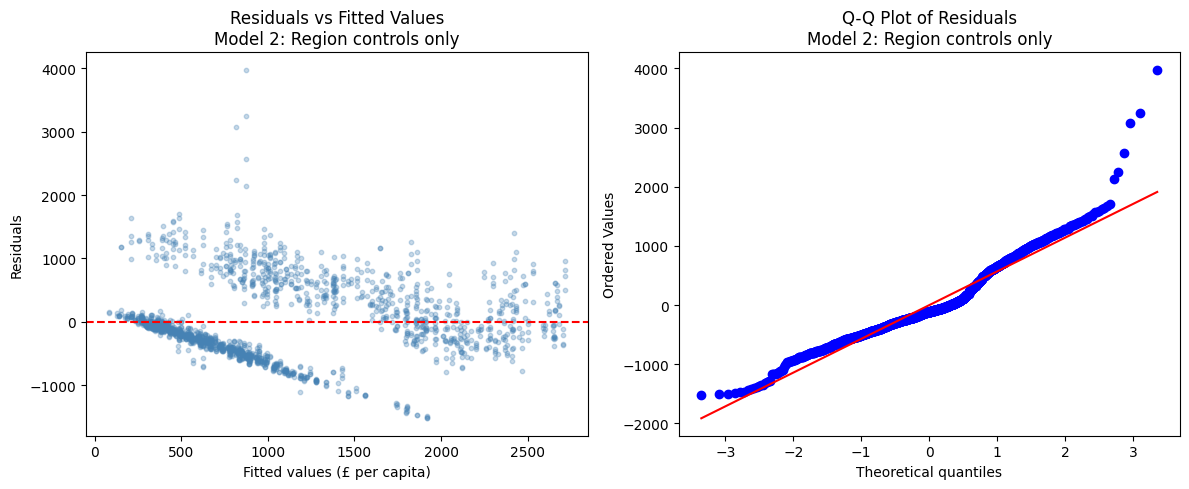

Diagnostic plots saved


In [10]:
# ============================================================
# DIAGNOSTIC PLOTS FOR MODEL 2
# ============================================================
# Check regression assumptions:
# 1. Residuals vs fitted (homoscedasticity)
# 2. Q-Q plot (normality of residuals)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs fitted
fitted = model2.fittedvalues
residuals = model2.resid

axes[0].scatter(fitted, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values (£ per capita)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values\nModel 2: Region controls only')

# Q-Q plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals\nModel 2: Region controls only')

plt.tight_layout()
plt.savefig('model2_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagnostic plots saved")


In [11]:
# ============================================================
# SENSITIVITY ANALYSIS 1 — Exclude COVID years
# ============================================================
# Decision D6: main model includes COVID years with boolean control
# This sensitivity tests whether excluding them changes the
# deprivation coefficient materially
# ============================================================

df_no_covid = df_reg[df_reg['is_covid_year'] == False].copy()
print(f"Observations excluding COVID years: {len(df_no_covid)}")

model_s1 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + C(region_name)',
    data=df_no_covid
).fit(cov_type='cluster', cov_kwds={'groups': df_no_covid['lad_code']})

print(f"\nSensitivity 1 — COVID years excluded:")
print(f"imd_score coefficient: {model_s1.params['imd_score']:.4f}")
print(f"imd_score p-value: {model_s1.pvalues['imd_score']:.4f}")
print(f"R-squared: {model_s1.rsquared:.4f}")

Observations excluding COVID years: 1147

Sensitivity 1 — COVID years excluded:
imd_score coefficient: 36.4764
imd_score p-value: 0.0000
R-squared: 0.5556


In [12]:
# ============================================================
# SENSITIVITY ANALYSES 2, 3, 4
# ============================================================
# S2: RS_totsx_net_exp (line 699) instead of RS_netcurrtot_net_exp
# S3: Adult social care per capita as dependent variable
# S4: Children's social care per capita as dependent variable
# ============================================================

sensitivities = {
    'S2 - Total service expenditure per capita': 'total_service_expenditure_per_capita',
    'S3 - Adult social care per capita': 'adult_social_care_per_capita',
    'S4 - Children social care per capita': 'childrens_social_care_per_capita'
}

for name, dep_var in sensitivities.items():
    model_s = smf.ols(
        formula=f'{dep_var} ~ imd_score + is_covid_year_int + C(region_name)',
        data=df_reg
    ).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

    print(f"\n{name}:")
    print(f"  imd_score coefficient: {model_s.params['imd_score']:.4f}")
    print(f"  imd_score p-value: {model_s.pvalues['imd_score']:.4f}")
    print(f"  R-squared: {model_s.rsquared:.4f}")


S2 - Total service expenditure per capita:
  imd_score coefficient: 28.1740
  imd_score p-value: 0.0000
  R-squared: 0.5003

S3 - Adult social care per capita:
  imd_score coefficient: 5.4665
  imd_score p-value: 0.0000
  R-squared: 0.4293

S4 - Children social care per capita:
  imd_score coefficient: 5.8818
  imd_score p-value: 0.0000
  R-squared: 0.4990


In [13]:
# ============================================================
# SENSITIVITY ANALYSIS 1 — Exclude COVID years
# ============================================================
# Decision D6: main model includes COVID years with boolean control
# This sensitivity tests whether excluding them changes the
# deprivation coefficient materially
# ============================================================

df_no_covid = df_reg[df_reg['is_covid_year'] == False].copy()
print(f"Observations excluding COVID years: {len(df_no_covid)}")

model_s1 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + C(region_name)',
    data=df_no_covid
).fit(cov_type='cluster', cov_kwds={'groups': df_no_covid['lad_code']})

print(f"\nSensitivity 1 — COVID years excluded:")
print(f"imd_score coefficient: {model_s1.params['imd_score']:.4f}")
print(f"imd_score p-value: {model_s1.pvalues['imd_score']:.4f}")
print(f"R-squared: {model_s1.rsquared:.4f}")

Observations excluding COVID years: 1147

Sensitivity 1 — COVID years excluded:
imd_score coefficient: 36.4764
imd_score p-value: 0.0000
R-squared: 0.5556


In [14]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================
# Random Forest captures non-linear relationships that OLS misses
# Feature set mirrors Model 2 exactly for direct comparability
# Decision D24: la_class excluded to avoid SHAP dilution
# 500 trees gives stable feature importance estimates
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap

# Create dummy variables for region — same as Model 2
df_rf = pd.get_dummies(
    df_reg[['imd_score', 'is_covid_year_int', 'region_name',
            'net_current_expenditure_per_capita', 'lad_code', 'la_name']],
    columns=['region_name'],
    drop_first=True,
    dtype=float
)

# Define features and target
feature_cols = [c for c in df_rf.columns if c not in
                ['net_current_expenditure_per_capita', 'lad_code', 'la_name']]
X = df_rf[feature_cols]
y = df_rf['net_current_expenditure_per_capita']

print(f"Features used: {feature_cols}")
print(f"Observations: {len(X)}")

# Split into train and test sets
# Using 80/20 split — standard for this size dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
# 500 trees for stable estimates, random_state for reproducibility
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1  # use all available CPU cores
)
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred)

print(f"\nRandom Forest R-squared on test set: {rf_r2:.4f}")
print(f"OLS Model 2 R-squared for comparison: 0.5624")

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance ranking:")
print(importance_df.to_string())

Features used: ['imd_score', 'is_covid_year_int', 'region_name_East of England', 'region_name_London', 'region_name_North East', 'region_name_North West', 'region_name_South East', 'region_name_South West', 'region_name_West Midlands', 'region_name_Yorkshire and The Humber']
Observations: 1727

Random Forest R-squared on test set: 0.9354
OLS Model 2 R-squared for comparison: 0.5624

Feature importance ranking:
                                feature  importance
0                             imd_score    0.579681
3                    region_name_London    0.265956
4                region_name_North East    0.028447
9  region_name_Yorkshire and The Humber    0.026418
2           region_name_East of England    0.024611
6                region_name_South East    0.023195
5                region_name_North West    0.019254
7                region_name_South West    0.018686
8             region_name_West Midlands    0.008422
1                     is_covid_year_int    0.005331


SHAP values calculated for 1727 observations
Features: ['imd_score', 'is_covid_year_int', 'region_name_East of England', 'region_name_London', 'region_name_North East', 'region_name_North West', 'region_name_South East', 'region_name_South West', 'region_name_West Midlands', 'region_name_Yorkshire and The Humber']


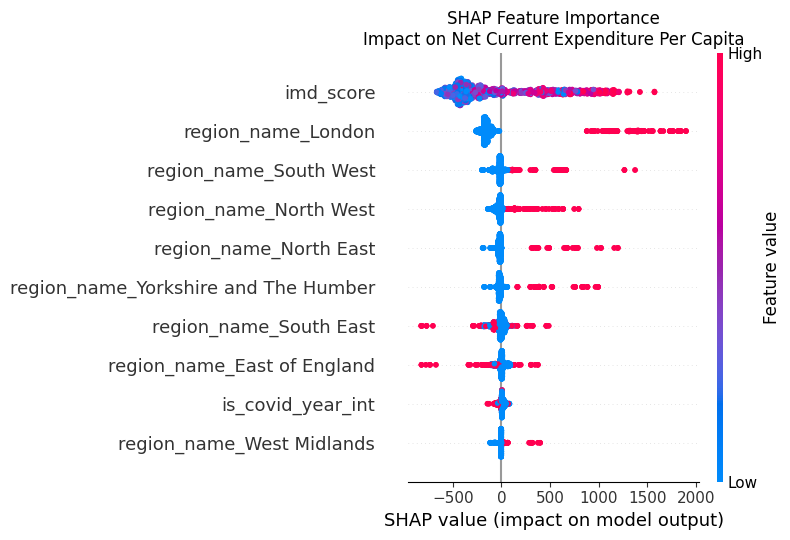

SHAP summary plot saved


In [15]:
# ============================================================
# SHAP VALUES — Individual Authority Explanation
# ============================================================
# SHAP explains WHY the RF predicted what it did for each
# authority — which features pushed the prediction up or down
# This partially addresses Busuioc's Explanation dimension
# for technically literate audiences
# Decision D24: SHAP via TreeExplainer for RF models
# ============================================================

# Calculate SHAP values using TreeExplainer
# TreeExplainer is exact and fast for Random Forest models
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

print(f"SHAP values calculated for {len(shap_values)} observations")
print(f"Features: {feature_cols}")

# Summary plot — shows overall feature importance via SHAP
shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance\nImpact on Net Current Expenditure Per Capita')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")

In [17]:
print(len(X))


1727


In [18]:
print(f"Random Forest R-squared on test set: {rf_r2:.4f}")

Random Forest R-squared on test set: 0.9354
